In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols, mixedlm
import time
from datetime import date

# updated src file changes are loaded
%load_ext autoreload
%autoreload 2

sys.path.append(os.path.abspath(".."))

In [2]:
### LOAD DATA

In [2]:
# load and combine experimet df

from src.loading import load_data

# -------------------- 3.0 m/s
df_3 = load_data("../data/target_trial_3_2025_11_7.parquet",  keep_col='training_status')
# ------------------- 2.0 m/s
df_2 = load_data("../data/target_trial_2.parquet")
# # drop every row from participant p030 due to corrupted data
df_2 = df_2[df_2['ppid'] != 'p030'].copy()

df_full = pd.concat([df_2, df_3], ignore_index=True)

In [4]:
### FORMAT DF

In [3]:

# add new variables

df_full['lateral_error_x'] = (df_full['min_pos_from_target_x'] - df_full['target_position_x']) 
df_full['depth_error_z'] = (df_full['min_pos_from_target_z'] - df_full['target_position_z']) 


# convert key columns to cm:
from src.convert_to_cm import convert_to_cm

df_labeled = convert_to_cm(df_full,
              cols=[
                    'min_pos_from_target_x',
                    'min_pos_from_target_z',
                    'target_position_x',
                    'target_position_z',
                    'lateral_error_x',
                    'depth_error_z'
                   ])

print('res:', df_labeled['target_position_x'].dtypes)

# label ppid by water speed
from src.label_water_speed_ppid import label_water_condtion_ppid
df_labeled = label_water_condtion_ppid(df_labeled, ppid_col='ppid', water_col='water_speed_m_s', selected_speeds=[-3.0,-2.0,0.0]).copy() 
# one-dimensional errors - in cm
#df_labeled['lateral_error_x_cm'] = (df_labeled['min_pos_from_target_x'] - df_labeled['target_position_x']) * 100 # convert to cm
#df_labeled['depth_error_z_cm'] = (df_labeled['min_pos_from_target_z'] - df_labeled['target_position_z']) * 100



# order targets

# adjust target label
target_mapping = {
    "p0.6": "R60",
    "p0.3": "R30",
    "neg0.3": "L30",
    "neg0.6": "L60"
}
df_labeled['target_x_label'] = df_labeled['target_x_label'].map(target_mapping).copy()

from src.features import order_targets
df_labeled['target_position_x'] = order_targets(df_labeled.copy())
df_labeled['target_x_label'] = order_targets(df_labeled.copy())




df_labeled['set_order'] = df_labeled['set_order'].replace({
    '1': '63_36',
    '2': '36_63'
}).copy()

# ensures PCA compatibility
df_labeled['water_speed_m_s'] = df_labeled['water_speed_m_s'].replace(0.0, 0.0001).copy()


# add temporal phase label categorical varible
from src.add_phases import label_phases, df_add_phases
phases = label_phases() 

df_labeled = df_add_phases(df_labeled, phase_array=phases).copy()


from src.add_cycles import add_cycles
df_labeled = add_cycles(df_labeled,
                       n_trials=4,
                       grouping_vars=['ppid_full','target_x_label'],
                       ).copy()

# filter out familiarization (i.e, starts with an 'f')
df_nf = df_labeled[~df_labeled['phase'].str.startswith('f')].copy()

# remove trials that do not cross a certain threshold in the z-plane (i.e, trials that did not exceed 70 cm in the z-plane)
from src.cleaning import crossed_threshold

# make column checking if ball crossed 70.0 cm on z axis
df_nf['crossed_threshold'] = df_nf.apply(
    lambda row: crossed_threshold(row, col="ball_pos_z", val=0.70), # 70 cm
        axis=1
).copy()
# check
print(df_nf['crossed_threshold'].value_counts())
print(df_nf['ball_pos_z'].describe())

# Make a seperate df without trials that did not cross threshold
df_filt = df_nf[df_nf['crossed_threshold']].copy() # retains rows where crossed_threshold == True

# reduce df to key cols
from src.cleaning import extract_key_columns
df_small_filt = extract_key_columns(df_filt).copy()


# check participant counts per group:
from src.features import get_sample_sizes
get_sample_sizes(df_small_filt, group_cols=['speed_label','experiment', 'set_order'], ppid_col='ppid_full')






res: float64
0        R30
1        R60
2        L60
3        L30
4        L30
        ... 
41160    R30
41161    R30
41162    L60
41163    R30
41164    L60
Name: target_x_label, Length: 41165, dtype: category
Categories (4, object): ['L60' < 'L30' < 'R30' < 'R60']
0        R30
1        R60
2        L60
3        L30
4        L30
        ... 
41160    R30
41161    R30
41162    L60
41163    R30
41164    L60
Name: target_x_label, Length: 41165, dtype: category
Categories (4, object): ['L60' < 'L30' < 'R30' < 'R60']


C:\Users\jacob\AppData\Local\Temp\ipykernel_22820\2419529776.py:49: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_labeled['set_order'] = df_labeled['set_order'].replace({
C:\Users\jacob\water_current_MA\src\add_phases.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['phase_target_trial_num'] = df.groupby(['ppid_full', 'phase', 'target_x_label']).cumcount() + 1
C:\Users\jacob\water_current_MA\src\add_cycles.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior o

crossed_threshold
True     39108
False      397
Name: count, dtype: int64
count                                                 39505
unique                                                39505
top       0.000000_0.013353_0.026616_0.052881_0.065885_0...
freq                                                      1
Name: ball_pos_z, dtype: object


C:\Users\jacob\water_current_MA\src\features.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(group_cols).size()


speed_label  experiment                       set_order
-3.0         S1-projectile_experiment         63_36         0
                                              36_63         0
             S1_3.0M-projectile_experiment 1  63_36        20
                                              36_63         0
             S2-projectile_experiment         63_36         0
                                              36_63         0
             S2_3.0M-projectile_experiment 1  63_36         0
                                              36_63        25
             projectile_experiment            63_36         0
                                              36_63         0
-2.0         S1-projectile_experiment         63_36        15
                                              36_63         0
             S1_3.0M-projectile_experiment 1  63_36         0
                                              36_63         0
             S2-projectile_experiment         63_36         0
              

In [9]:
df_small_filt.columns

Index(['experiment', 'ppid_full', 'speed_label', 'target_x_label',
       'target_position_x_cm', 'target_position_z_cm', 'trial_num', 'phase',
       'phase_target_trial_num', 'trial_num_target', 'cycle_target_num',
       'cycle_TargetxPhase_num', 'launch_deviation', 'launch_Speed',
       'ball_dist_to_center_cm', 'lateral_error_x_cm', 'depth_error_z_cm',
       'target_hit', 'water_speed_binary', 'water_speed_m_s', 'sign_label',
       'set_order', 'min_pos_from_target_x_cm', 'min_pos_from_target_z_cm',
       'target_angle_90'],
      dtype='object')

In [6]:
### APPLY PCA

In [7]:
from src.PCA import compute_PCA_summary

PCA_table = compute_PCA_summary(df_small_filt,
            features = ['min_pos_from_target_x_cm','min_pos_from_target_z_cm'],
            group_cols = ['water_speed_m_s','set_order','target_position_x_cm'],
            water_col = 'water_speed_m_s',
            n_components=2
            )
PCA_table


# extract relevant columns
PCA_table_small = PCA_table.iloc[:, 0:9].copy()
PCA_table_small


# merge small summary table into raw df with trial-by-trial data
df_angles = df_small_filt.copy()

group_cols = ['water_speed_m_s','set_order','target_position_x_cm']

new_cols = ['pc_vector_1_angle','pc_vector_1_pca_center_x','pc_vector_1_pca_center_z','pc_vector_1_c_X','pc_vector_1_c_Z']

df_angles_v = df_angles.merge(PCA_table_small[group_cols + new_cols], how="left", on=group_cols)

from src.PCA import compute_PCA_error

PCA_error_df = compute_PCA_error(trial_df=df_angles_v,
                  pc_deg='pc_vector_1_angle',
                  target_x_col='target_position_x_cm',
                  target_z_col='target_position_z_cm',
                  features = ['min_pos_from_target_x_cm','min_pos_from_target_z_cm'],
                  water_col = 'water_speed_m_s'
                 )
print(PCA_error_df.columns)
PCA_error_df

Index(['experiment', 'ppid_full', 'speed_label', 'target_x_label',
       'target_position_x_cm', 'target_position_z_cm', 'trial_num', 'phase',
       'phase_target_trial_num', 'trial_num_target', 'cycle_target_num',
       'cycle_TargetxPhase_num', 'launch_deviation', 'launch_Speed',
       'ball_dist_to_center_cm', 'lateral_error_x_cm', 'depth_error_z_cm',
       'target_hit', 'water_speed_binary', 'water_speed_m_s', 'sign_label',
       'set_order', 'min_pos_from_target_x_cm', 'min_pos_from_target_z_cm',
       'target_angle_90', 'pc_vector_1_angle', 'pc_vector_1_pca_center_x',
       'pc_vector_1_pca_center_z', 'pc_vector_1_c_X', 'pc_vector_1_c_Z',
       'pc_rad', 'centered_x', 'centered_z', 'unrotated_x', 'unrotated_z',
       'tgt_centered_x', 'tgt_centered_z', 'tgt_unrotated_x',
       'tgt_unrotated_z', 'PCA_error_X_cm', 'PCA_error_Z_cm'],
      dtype='object')


C:\Users\jacob\water_current_MA\src\PCA.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_group = data_current.groupby(group_cols)


,experiment,ppid_full,speed_label,target_x_label,target_position_x_cm,target_position_z_cm,trial_num,phase,phase_target_trial_num,trial_num_target,...,centered_x,centered_z,unrotated_x,unrotated_z,tgt_centered_x,tgt_centered_z,tgt_unrotated_x,tgt_unrotated_z,PCA_error_X_cm,PCA_error_Z_cm
0,projectile_experiment,p000_neg2,-2.0,R60,60.0,140.0,21,baseline,1,6,...,-8.422014,0.849144,7.821262,3.237162,-2.979414,7.283544,6.071253,-5.006676,1.750010,8.243838
1,projectile_experiment,p000_neg2,-2.0,L30,-30.0,140.0,22,baseline,1,6,...,9.450194,4.763292,-9.260686,-5.121993,-5.684806,4.519692,5.853857,-4.298488,-15.114543,-0.823505
2,projectile_experiment,p000_neg2,-2.0,R30,30.0,140.0,23,baseline,1,6,...,-3.291001,-0.622905,2.759994,1.897666,-6.701501,7.220195,9.044805,-3.902927,-6.284811,5.800593
3,projectile_experiment,p000_neg2,-2.0,L60,-60.0,140.0,24,baseline,1,6,...,-6.100778,-2.752574,5.920209,3.122064,-8.935278,5.019826,9.226709,-4.461580,-3.306500,7.583644
4,projectile_experiment,p000_neg2,-2.0,R60,60.0,140.0,25,baseline,2,7,...,0.636586,0.188844,-0.471448,-0.467591,-2.979414,7.283544,6.071253,-5.006676,-6.542700,4.539085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39103,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,R30,30.0,140.0,492,washout_2,34,122,...,-18.245816,8.402305,20.037318,-1.419301,-5.212916,6.560305,7.193396,-4.297341,12.843922,2.878040
39104,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,R30,30.0,140.0,493,washout_2,35,123,...,-1.522216,1.354205,1.902303,-0.729558,-5.212916,6.560305,7.193396,-4.297341,-5.291093,3.567783
39105,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,L60,-60.0,140.0,494,washout_2,35,123,...,1.604181,1.611923,1.744044,1.459453,-5.964219,4.917723,-5.492578,5.439439,7.236622,-3.979986
39106,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,R30,30.0,140.0,495,washout_2,36,124,...,-12.965716,6.017105,14.255134,-1.051908,-5.212916,6.560305,7.193396,-4.297341,7.061737,3.245434


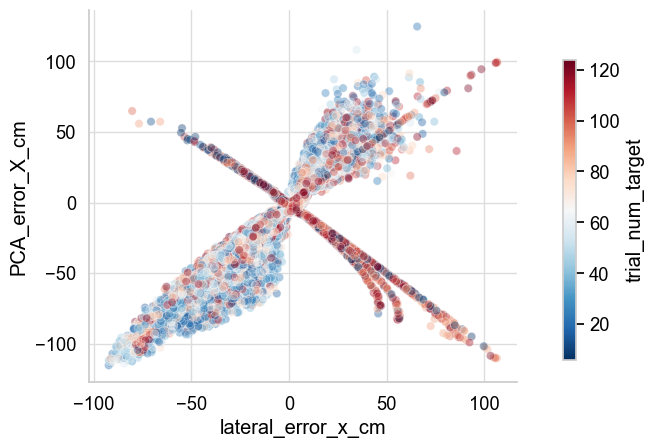

In [13]:
from src.plotting import plot_heatmap

plot_heatmap(PCA_error_df,
                     x_col = 'lateral_error_x_cm',
                     y_col='PCA_error_X_cm',
                     colour_col='trial_num_target',
                     mode='correlation', 
                     dark=False)

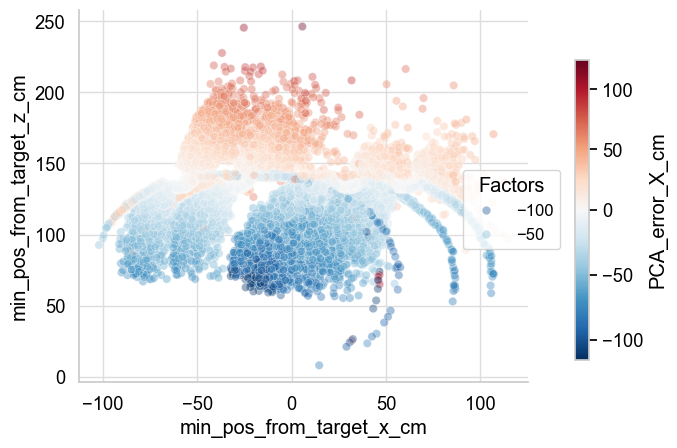

In [15]:
from src.plotting import plot_heatmap

plot_heatmap(PCA_error_df,
                     x_col = 'min_pos_from_target_x_cm',
                     y_col='min_pos_from_target_z_cm',
                     colour_col='PCA_error_X_cm',
                     mode='correlation', 
                     dark=False)

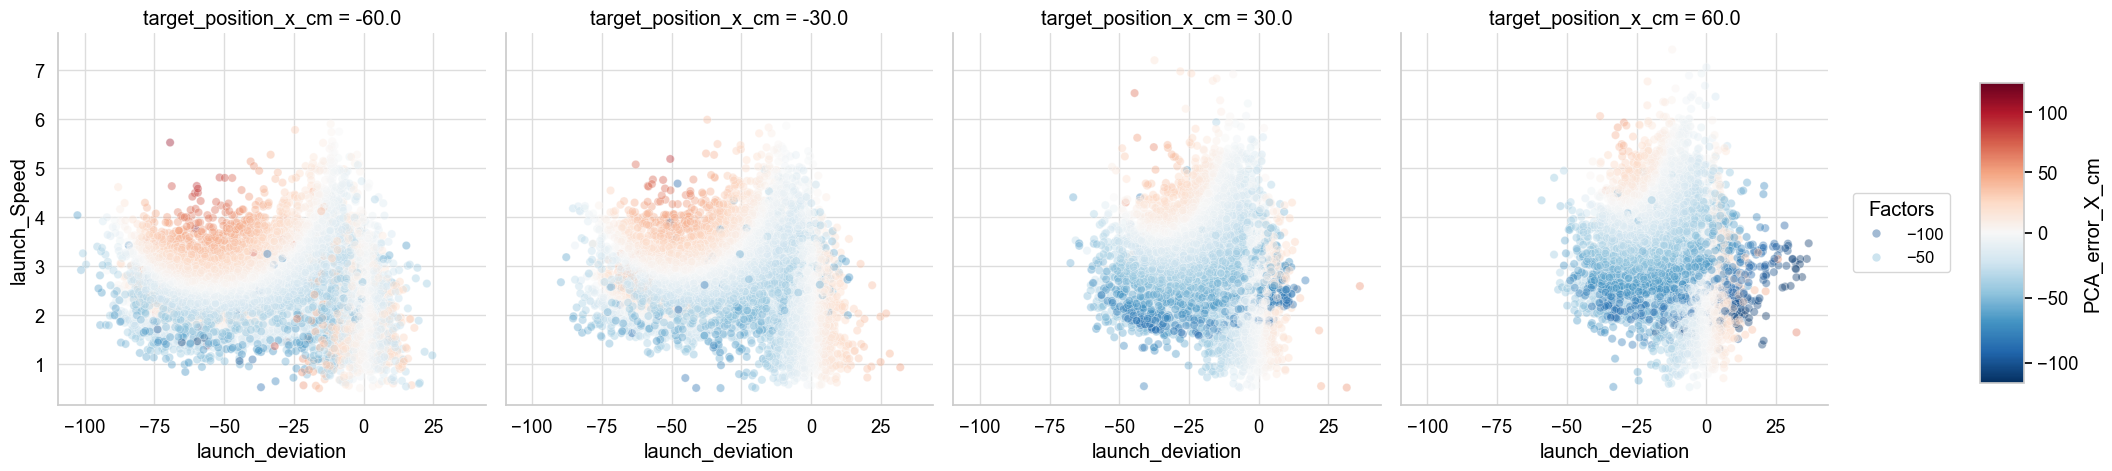

In [17]:
from src.plotting import plot_heatmap

plot_heatmap(PCA_error_df,
                     x_col = 'launch_deviation',
                     y_col='launch_Speed',
                     colour_col='PCA_error_X_cm',
                     facet_col='target_position_x_cm',
                     dark=False)

In [ ]:
### remove outliers

In [177]:
from src.cleaning import flag_outlier_participants

outliers = flag_outlier_participants(PCA_error_df,
                            y_col='PCA_error_X_cm'
                               )

PCA_error_df_filtered = PCA_error_df[~PCA_error_df['ppid_full'].isin(outliers)]


print('BEFORE:', PCA_error_df.shape)
print('AFTER:', PCA_error_df_filtered.shape)

--- Inter-Subject Outlier Detection (PCA_error_X_cm) ---
Participants exceeding 2 SD from group mean: ['p004_neg2', 'p005_neg3', 'p007_neg3', 'p015_neg3', 'p020_neg3', 'p024_neg2', 'p027_neg3', 'p034_neg3', 'p035_neg3', 'p039_neg3', 'p046_neg3']

Target breakdown for outliers:
     ppid_full target_x_label  subj_target_mean  group_target_mean
20   p004_neg2            L60         24.643241          -1.308684
33   p005_neg3            L30         18.744436          -4.337782
35   p005_neg3            R60        -31.648812          -5.036908
48   p007_neg3            L60        -55.683306          -1.308684
49   p007_neg3            L30        -31.882721          -4.337782
50   p007_neg3            R30        -23.414011          -6.206023
96   p015_neg3            L60        -31.152712          -1.308684
99   p015_neg3            R60        -28.333625          -5.036908
127  p020_neg3            R60         20.635104          -5.036908
150  p024_neg2            R30        -29.294238     

C:\Users\jacob\water_current_MA\src\cleaning.py:81: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  
C:\Users\jacob\water_current_MA\src\cleaning.py:85: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_baseline = df_baseline.rename(columns={y_col: f"{y_col}_mean"})
C:\Users\jacob\water_current_MA\src\cleaning.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  


In [179]:
from src.baseline_correct import baseline_correct

df_bc = baseline_correct(data = PCA_error_df_filtered,
                phase_col = 'phase',
                baseline_string='baseline',
                y_col='PCA_error_X_cm' # lateral_error_x_cm
                ) 
df_bc

BASELINE: (2303, 41)


C:\Users\jacob\water_current_MA\src\baseline_correct.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_baseline = df_filtered.groupby(grouping_vars)[y_col].mean().reset_index()


,experiment,ppid_full,speed_label,target_x_label,target_position_x_cm,target_position_z_cm,trial_num,phase,phase_target_trial_num,trial_num_target,...,unrotated_x,unrotated_z,tgt_centered_x,tgt_centered_z,tgt_unrotated_x,tgt_unrotated_z,PCA_error_X_cm,PCA_error_Z_cm,PCA_error_X_cm_mean,PCA_error_X_cm_bc
0,projectile_experiment,p000_neg2,-2.0,R60,60.0,140.0,21,baseline,1,6,...,7.821262,3.237162,-2.979414,7.283544,6.071253,-5.006676,1.750010,8.243838,-4.548843,6.298853
1,projectile_experiment,p000_neg2,-2.0,L30,-30.0,140.0,22,baseline,1,6,...,-9.260686,-5.121993,-5.684806,4.519692,5.853857,-4.298488,-15.114543,-0.823505,-15.881028,0.766485
2,projectile_experiment,p000_neg2,-2.0,R30,30.0,140.0,23,baseline,1,6,...,2.759994,1.897666,-6.701501,7.220195,9.044805,-3.902927,-6.284811,5.800593,-12.955783,6.670971
3,projectile_experiment,p000_neg2,-2.0,L60,-60.0,140.0,24,baseline,1,6,...,5.920209,3.122064,-8.935278,5.019826,9.226709,-4.461580,-3.306500,7.583644,-8.811999,5.505500
4,projectile_experiment,p000_neg2,-2.0,R60,60.0,140.0,25,baseline,2,7,...,-0.471448,-0.467591,-2.979414,7.283544,6.071253,-5.006676,-6.542700,4.539085,-4.548843,-1.993857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34033,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,R30,30.0,140.0,492,washout_2,34,122,...,20.037318,-1.419301,-5.212916,6.560305,7.193396,-4.297341,12.843922,2.878040,-3.369440,16.213361
34034,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,R30,30.0,140.0,493,washout_2,35,123,...,1.902303,-0.729558,-5.212916,6.560305,7.193396,-4.297341,-5.291093,3.567783,-3.369440,-1.921653
34035,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,L60,-60.0,140.0,494,washout_2,35,123,...,1.744044,1.459453,-5.964219,4.917723,-5.492578,5.439439,7.236622,-3.979986,1.594520,5.642103
34036,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,R30,30.0,140.0,495,washout_2,36,124,...,14.255134,-1.051908,-5.212916,6.560305,7.193396,-4.297341,7.061737,3.245434,-3.369440,10.431177


In [ ]:
### SAVE PCA OUPUT DF

In [181]:

# Extract and join unique experiment strings
exp_tags = "_".join(df_bc['experiment'].unique().astype(str))

# Extract unique water speeds, rounded to prevent floating point noise
speeds = df_bc['water_speed_m_s'].unique()
speed_tags = "_".join([str(round(s, 1)).replace('-', 'neg').replace('.', '_') for s in np.sort(speeds)])

# construct the combined filename
file_name = f"PCA_error_{exp_tags}_speed_{speed_tags}.csv"
file_path = f"..\\data\\{file_name}"

df_bc.to_csv(file_path, index=False)
print(f"Saved: {file_path}")

Saved: ..\data\PCA_error_projectile_experiment _S1-projectile_experiment_S2-projectile_experiment_S1_3.0M-projectile_experiment 1_S2_3.0M-projectile_experiment 1_speed_neg3_0_neg2_0_0_0.csv


In [183]:
from src.early_late_exposure import early_late_phase

early_late_phase_df = early_late_phase(df = df_bc,
                 group_cols = ['ppid_full','set_order','target_x_label','speed_label'],
                 phase_col = 'phase',
                 phases_to_keep=['training_1','training_2'],
                 trial_col = 'phase_target_trial_num',
                 n_trials = 4
                ).copy()

# Extract and join unique experiment strings
exp_tags = "_".join(early_late_phase_df['experiment'].unique().astype(str))

# Extract unique water speeds, rounded to prevent floating point noise
speeds = early_late_phase_df['water_speed_m_s'].unique()
speed_tags = "_".join([str(round(s, 1)).replace('-', 'neg').replace('.', '_') for s in np.sort(speeds)])

# construct the combined filename
file_name = f"early_late_phase_PCA_error_{exp_tags}_speed_{speed_tags}.csv"
file_path = f"..\\data\\{file_name}"

early_late_phase_df.to_csv(file_path, index=False)
print(f"Saved: {file_path}")

Saved: ..\data\early_late_phase_PCA_error_projectile_experiment _S1-projectile_experiment_S2-projectile_experiment_S1_3.0M-projectile_experiment 1_S2_3.0M-projectile_experiment 1_speed_neg3_0_neg2_0.csv


C:\Users\jacob\water_current_MA\src\early_late_exposure.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_max = df.groupby(group_cols + [phase_col])[trial_col].transform('max')


In [185]:
early_late_phase_df

,experiment,ppid_full,speed_label,target_x_label,target_position_x_cm,target_position_z_cm,trial_num,phase,phase_target_trial_num,trial_num_target,...,unrotated_z,tgt_centered_x,tgt_centered_z,tgt_unrotated_x,tgt_unrotated_z,PCA_error_X_cm,PCA_error_Z_cm,PCA_error_X_cm_mean,PCA_error_X_cm_bc,trial_set
31,projectile_experiment,p000_neg2,-2.0,R30,30.0,140.0,53,training_1,1,14,...,10.806759,8.382967,11.111359,13.763199,2.076246,-69.002665,8.730513,-12.955783,-56.046882,early
32,projectile_experiment,p000_neg2,-2.0,L60,-60.0,140.0,54,training_1,1,14,...,3.859345,-5.706394,-5.887334,-7.875056,2.281911,-49.191112,1.577434,-8.811999,-40.379113,early
33,projectile_experiment,p000_neg2,-2.0,R30,30.0,140.0,55,training_1,2,15,...,6.603751,8.382967,11.111359,13.763199,2.076246,-52.198287,4.527506,-12.955783,-39.242504,early
34,projectile_experiment,p000_neg2,-2.0,L60,-60.0,140.0,56,training_1,2,15,...,-5.905637,-5.706394,-5.887334,-7.875056,2.281911,-73.288129,-8.187547,-8.811999,-64.476129,early
35,projectile_experiment,p000_neg2,-2.0,R30,30.0,140.0,57,training_1,3,16,...,-4.536847,8.382967,11.111359,13.763199,2.076246,-76.411272,-6.613093,-12.955783,-63.455489,early
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33961,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,R30,30.0,140.0,420,training_2,73,86,...,-0.978044,13.151371,12.686857,18.136348,2.233333,-15.139640,-3.211377,-3.369440,-11.770201,late
33962,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,R30,30.0,140.0,421,training_2,74,87,...,-0.607391,13.151371,12.686857,18.136348,2.233333,-57.775464,-2.840724,-3.369440,-54.406025,late
33963,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,L60,-60.0,140.0,422,training_2,74,87,...,-4.967341,-4.459149,-2.373704,-4.319462,2.619298,3.424326,-7.586639,1.594520,1.829806,late
33964,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,L60,-60.0,140.0,423,training_2,75,88,...,-5.394933,-4.459149,-2.373704,-4.319462,2.619298,-3.493281,-8.014231,1.594520,-5.087800,late


In [ ]:
### PLOTS

C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\axisgrid.py:854: UserWarni

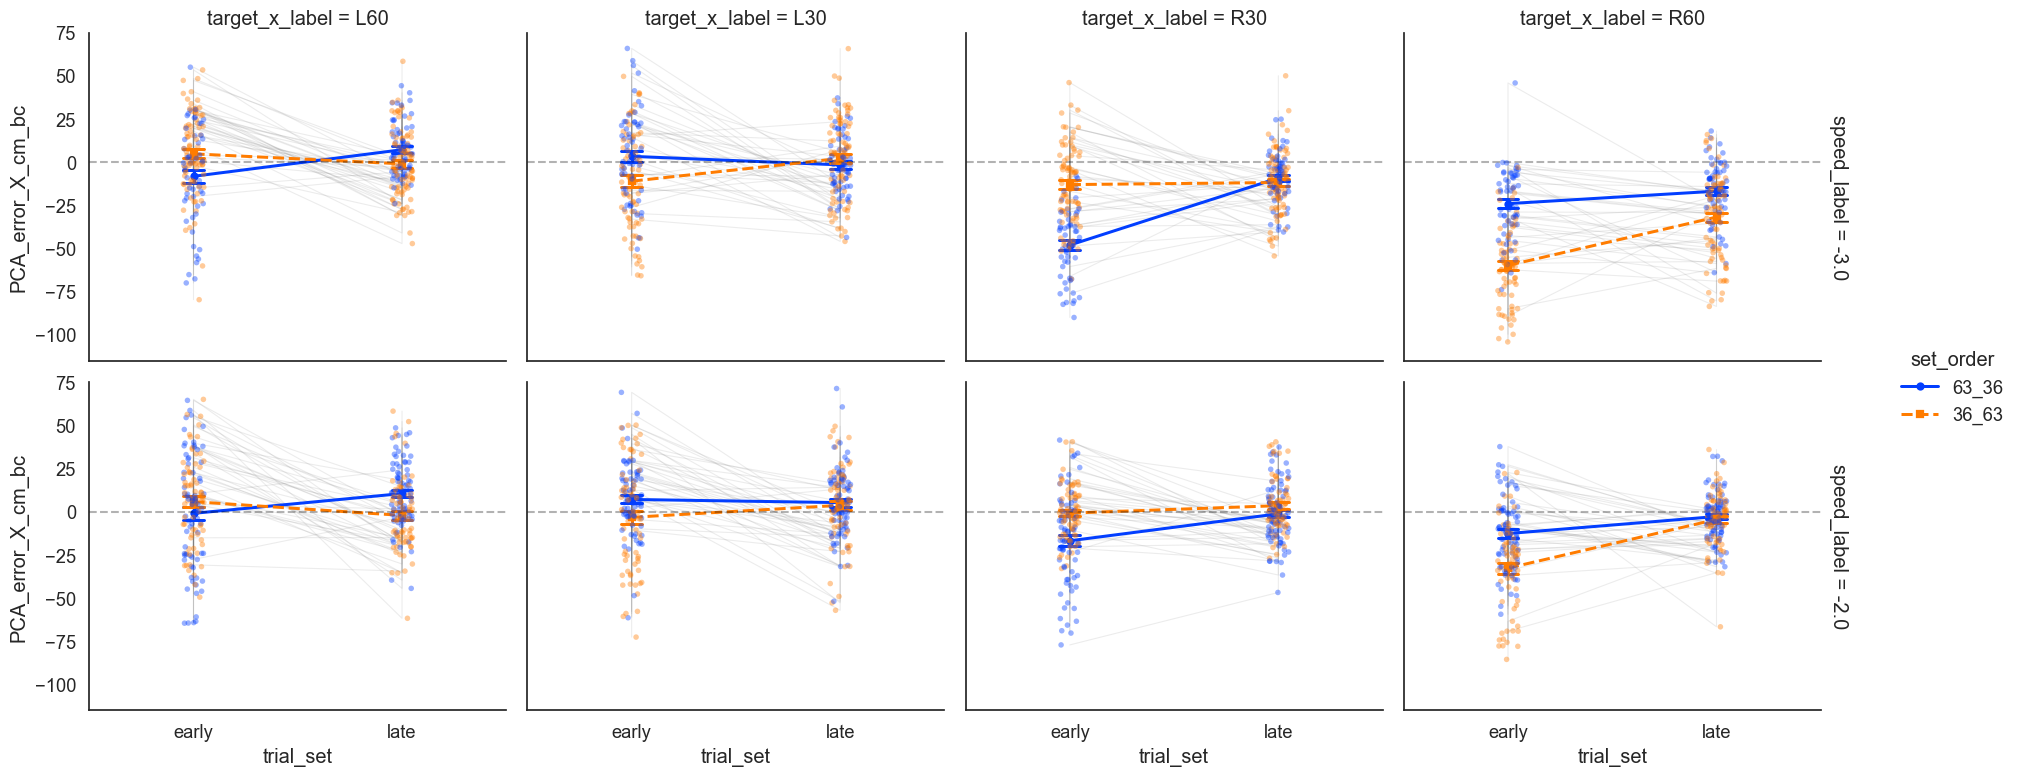

In [217]:
from src.plotting import plot_early_late_exposure

plot_early_late_exposure(early_late_phase_df,
                         x_col='trial_set',
                         y_col='PCA_error_X_cm_bc',
                         ylim=(-115,75),
                         line_col='speed_label',
                         cond_col='set_order', 
                         ppid_col='ppid_full',
                         facet_row='speed_label',
                         facet_col='target_x_label',
                         show_zero_line=True)

C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

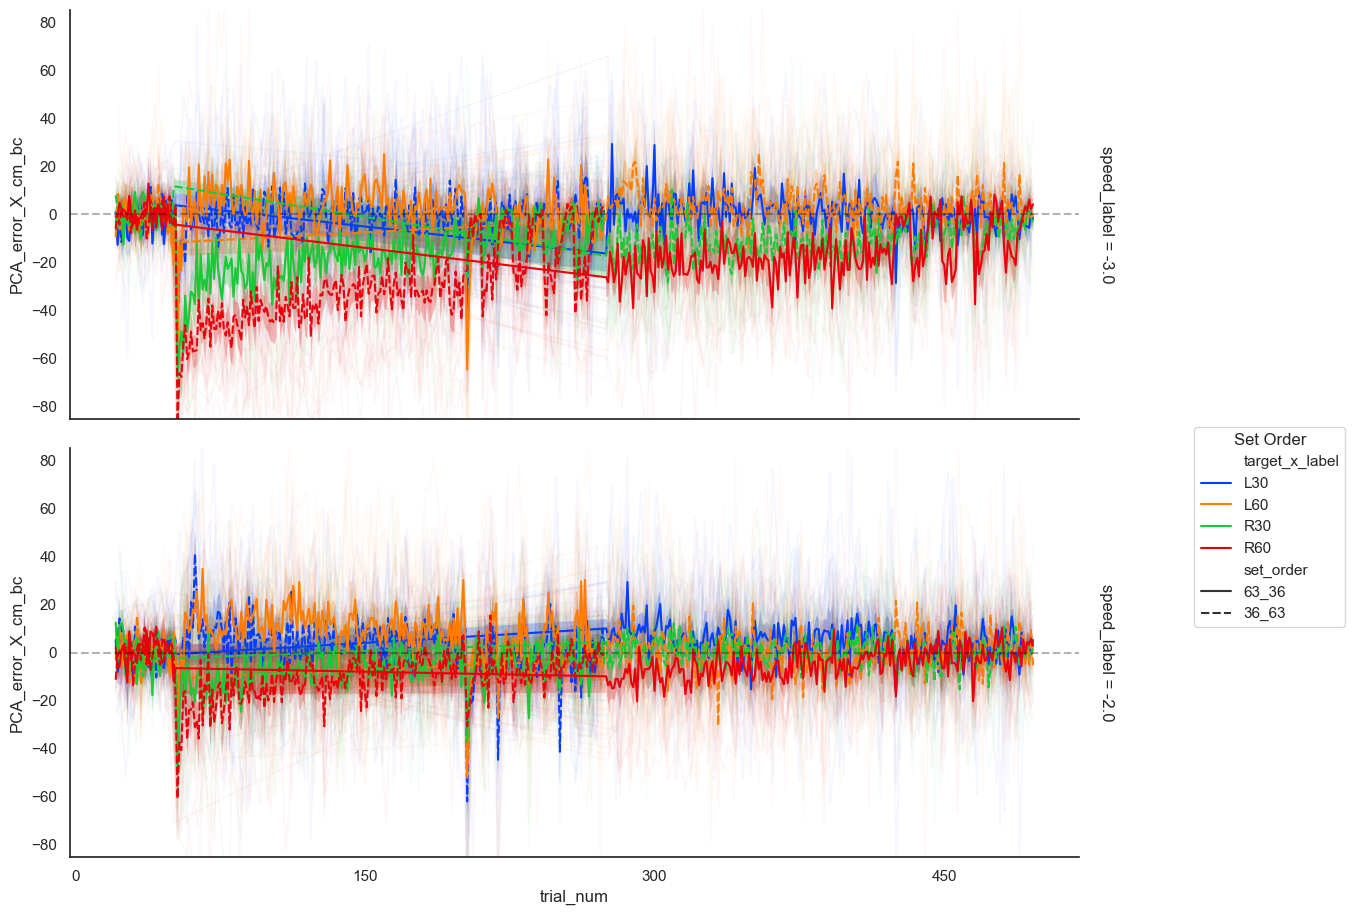

In [197]:
from src.plotting import plot_exposure_trials


plot_exposure_trials(df_bc, 
                     col_col = None,
                     row_col='speed_label',
                     cond_col='set_order',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'PCA_error_X_cm_bc', 
                     x_col='trial_num',
                     context='poster', 
                     font_scale=3,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-85,85),
                     show_zero_line=True
                    )

In [ ]:
# above is using: x = trial_num_target / y = PCA_error_X_cm

In [ ]:
from src.plotting import plot_exposure_trials


plot_exposure_trials(PCA_error_df, 
                     col_col=None,
                     row_col='speed_label',
                     cond_col='set_order',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'launch_deviation', 
                     x_col='trial_num',
                     context='poster', 
                     font_scale=3,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-70,35),
                     show_zero_line=True
                    )

In [ ]:
# above is using: x = trial_num_target / y = launch_deviation

In [ ]:
from src.plotting import plot_exposure_trials


plot_exposure_trials(PCA_error_df, 
                     col_col=None,
                     row_col='speed_label',
                     cond_col='set_order',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'launch_Speed', 
                     x_col='trial_num',
                     context='poster', 
                     font_scale=3,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(0.5,6.5),
                     show_zero_line=True
                    )

In [ ]:
# above is using: x = trial_num_target / y = launch_Speed

In [ ]:
from src.plotting import plot_exposure_trials


plot_exposure_trials(PCA_error_df, 
                     row_col='speed_label',
                     col_col='phase',
                     cond_col='set_order',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'PCA_error_X_cm', 
                     x_col='phase_target_trial_num',
                     context='poster', 
                     font_scale=3,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-85,85),
                     show_zero_line=True
                    )

In [ ]:
# above is using: x = phase_target_trial_num / y = PCA_error_X_cm

In [ ]:
from src.plotting import plot_exposure_trials


plot_exposure_trials(PCA_error_df, 
                     row_col='speed_label',
                     col_col='phase',
                     cond_col='set_order',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'launch_deviation', 
                     x_col='phase_target_trial_num',
                     context='poster', 
                     font_scale=3,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-65,65),
                     show_zero_line=True
                    )

In [ ]:
# above is using: x = phase_target_trial_num / y = launch_deviation

In [ ]:
from src.plotting import plot_exposure_trials


plot_exposure_trials(PCA_error_df, 
                     row_col='speed_label',
                     col_col='phase',
                     cond_col='set_order',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'launch_Speed', 
                     x_col='phase_target_trial_num',
                     context='poster', 
                     font_scale=3,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(0.5,6.5),
                     show_zero_line=True
                    )

In [ ]:
# above is using: x = phase_target_trial_num / y = launch_Speed

In [21]:
from src.early_late_exposure import early_late_phase

df_trial_sets = early_late_phase(df = filtered_df,
                 group_cols = ['ppid_full','set_order','target_x_label','speed_label'],
                 phase_col = 'phase',
                 trial_col = 'phase_target_trial_num',
                 n_trials = 4
                )
df_trial_sets

NameError: name 'filtered_df' is not defined

In [19]:
from src.plotting import plot_early_late_exposure

plot_early_late_exposure(df_trial_sets,
                         x_col='trial_set',
                         y_col='PCA_error_X_cm',
                         ylim=(-35,35),
                         line_col='set_order',
                         cond_col='speed_label', 
                         ppid_col='ppid_full',
                         facet_row='set_order',
                         facet_col='target_x_label',
                         show_zero_line=True)
#plot_early_late_exposure(early_late_10_means_dev)
#plot_early_late_exposure(early_late_10_means_speed)

NameError: name 'df_trial_sets' is not defined

In [69]:
df_bc.columns

Index(['experiment', 'ppid_full', 'speed_label', 'target_x_label',
       'target_position_x_cm', 'target_position_z_cm', 'trial_num', 'phase',
       'phase_target_trial_num', 'trial_num_target', 'cycle_target_num',
       'cycle_TargetxPhase_num', 'launch_deviation', 'launch_Speed',
       'ball_dist_to_center_cm', 'lateral_error_x_cm', 'depth_error_z_cm',
       'target_hit', 'water_speed_binary', 'water_speed_m_s', 'sign_label',
       'set_order', 'min_pos_from_target_x_cm', 'min_pos_from_target_z_cm',
       'target_angle_90', 'pc_vector_1_angle', 'pc_vector_1_pca_center_x',
       'pc_vector_1_pca_center_z', 'pc_vector_1_c_X', 'pc_vector_1_c_Z',
       'pc_rad', 'centered_x', 'centered_z', 'unrotated_x', 'unrotated_z',
       'tgt_centered_x', 'tgt_centered_z', 'tgt_unrotated_x',
       'tgt_unrotated_z', 'PCA_error_X_cm', 'PCA_error_Z_cm',
       'PCA_error_X_cm_mean', 'PCA_error_X_cm_bc'],
      dtype='object')